<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Dimension010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

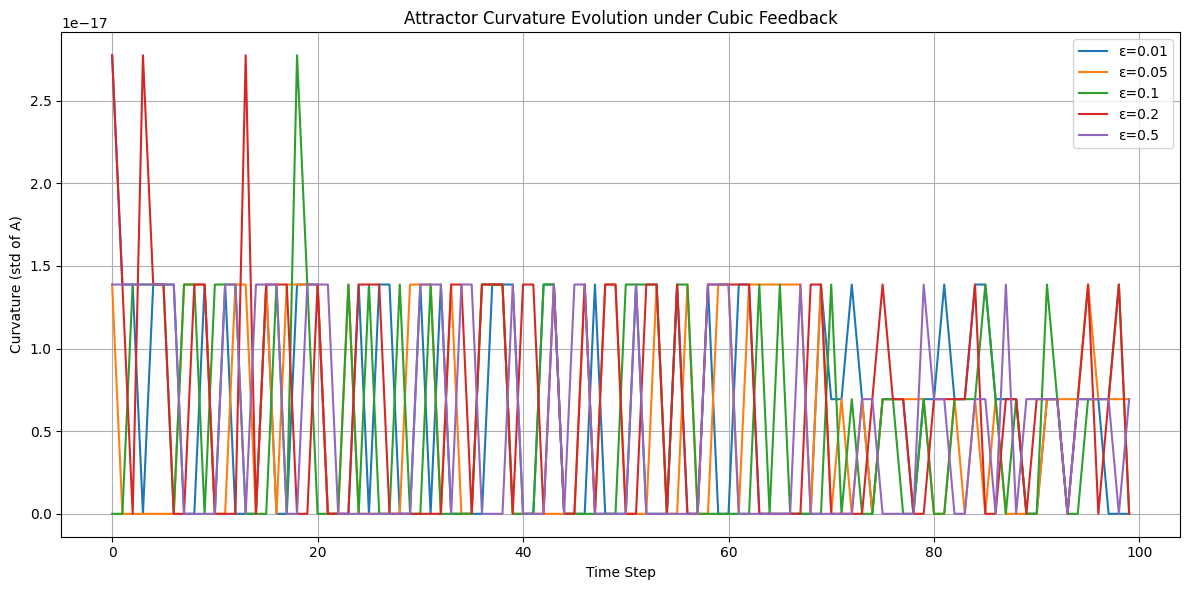

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Parameters
# -------------------------------
kappa = 0.2
delta = 0.02
gamma0 = 0.5
xi = 0.01
A0 = 0.1
time_steps = 100
grid_size = 50
epsilons = [0.01, 0.05, 0.1, 0.2, 0.5]

# -------------------------------
# Curvature Extraction Function
# -------------------------------
def evolve_and_extract_curvature(epsilon):
    A = np.ones(grid_size) * A0
    curvature_history = []

    for t in range(time_steps):
        laplacian = np.roll(A, -1) - 2 * A + np.roll(A, 1)
        dA_dt = -kappa * A + delta * A**2 + epsilon * A**3 + gamma0 * laplacian + xi
        A += dA_dt * 0.1

        # Curvature proxy: standard deviation across grid
        curvature = np.std(A)
        curvature_history.append(curvature)

    return curvature_history

# -------------------------------
# Run Sweep and Plot
# -------------------------------
plt.figure(figsize=(12, 6))
for eps in epsilons:
    curvature = evolve_and_extract_curvature(eps)
    plt.plot(curvature, label=f'ε={eps}')
plt.title("Attractor Curvature Evolution under Cubic Feedback")
plt.xlabel("Time Step")
plt.ylabel("Curvature (std of A)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
